# Python scripts

In [ ]:
!python generate_data.py

In [ ]:
!python tucker.py

In [3]:
!python generate_current.py

Saving to: data/Maxwell
Training parameters: 160
Q-DEIM rank: 80
N_E (DOFs): 49320
n_cells: 40500, n_local_dofs: 6
  assembled 1/160
  assembled 20/160
  assembled 40/160
  assembled 60/160
  assembled 80/160
  assembled 100/160
  assembled 120/160
  assembled 140/160
  assembled 160/160
J_snap shape: (49320, 160)
J_snap norm range: [2.4564e-01, 2.4862e-01]

Computing truncated SVD (rank=80)...
Singular values (first 10): [1.97700899 1.17009658 1.1046453  0.99947052 0.66827836 0.6238848
 0.55515147 0.46264809 0.42239025 0.38997221]
Singular values (last 5):   [0.00409726 0.00377631 0.00365149 0.00348753 0.00338351]
Relative energy in first 80 modes: 0.9999910976

Computing Q-DEIM indices (p=80)...
DEIM indices (first 10): [ 4685  5366  5862  6190  7774  8237  9033  9691  9728 11394]
Condition number of P^T U_J: 6.6584e+00

Finding reduced element set...
Reduced cells: 480 / 40500 (1.2%)

Verifying DEIM approximation on training data...
DEIM reconstruction error (training):
  mean:   4.

# Imports

In [1]:
import os
import numpy as np

os.chdir("../..")
savedir = "data/Maxwell"

In [2]:
import scipy.sparse as sp
from tensorly.tucker_tensor import TuckerTensor
from src.Maxwell.error_sweeps import *
from src.Maxwell.ROM import *
from src.Maxwell.FOM import *
from src.Utils.utils import *
from src.Bases.rbf import RBFWeights
from src.Bases.lidw import lidw
import matplotlib.pyplot as plt

In [3]:
filename = 'src/Maxwell/maxwell_data.hdf5'
file_hdf5 = h5py.File(filename, 'r')
sim = MaxwellSim(file_hdf5)

M_E = sim.emass
M_B = sim.bmass
#M_B = sp.eye(sim.bmass.shape[0])
Wk = sim.wkcurl
St = sim.stcurl

# Load Q-DEIM data

In [4]:
qdeim_data = np.load(os.path.join(savedir, "qdeim_current.npz"))
U_J = qdeim_data["U_J"]
deim_idx = qdeim_data["deim_idx"]
P_UJ_inv = qdeim_data["P_UJ_inv"]
coords_r = qdeim_data["coords_r"]
weighted_basis_r = qdeim_data["weighted_basis_r"]
gids_r = qdeim_data["gids_r"]

hyper_kwargs = dict(
    U_J=U_J, deim_idx=deim_idx, P_UJ_inv=P_UJ_inv,
    coords_r=coords_r, weighted_basis_r=weighted_basis_r, gids_r=gids_r,
)

print(f"Q-DEIM rank: {U_J.shape[1]}")
print(f"DEIM DOFs: {len(deim_idx)}")
print(f"Reduced cells: {gids_r.shape[0]}")
print(f"Cond(P^T U_J): {np.linalg.cond(U_J[deim_idx, :]):.4e}")

Q-DEIM rank: 100
DEIM DOFs: 100
Reduced cells: 600
Cond(P^T U_J): 8.5674e+00


In [5]:
with np.load(os.path.join(savedir, "params_train.npz")) as z:
    params_train = z["params"]

snapshots_B_train = np.load(os.path.join(savedir, "maxwell_B_train_f32.npy"), mmap_mode="r")
snapshots_E_train = np.load(os.path.join(savedir, "maxwell_E_train_f32.npy"), mmap_mode="r")

snapshots_E_train.shape, snapshots_B_train.shape, params_train.shape


((49320, 121, 160), (82350, 121, 160), (160, 3))

In [6]:
with np.load(os.path.join(savedir, "maxwell_B_test.npz")) as z:
    snapshots_B_test = z["B"]
    params_test = z["params"]
    times = z["t"]

with np.load(os.path.join(savedir, "maxwell_E_test.npz")) as z:
    snapshots_E_test = z["E"]
    params_test = z["params"]

snapshots_E_test.shape, snapshots_B_test.shape, params_test.shape

((49320, 121, 40), (82350, 121, 40), (40, 3))

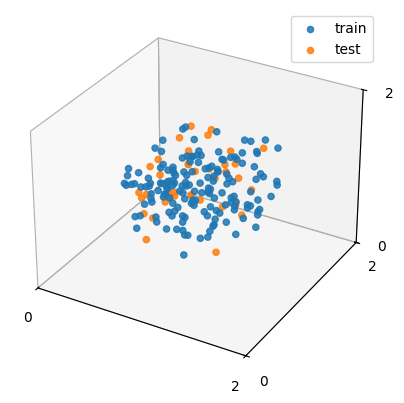

In [7]:
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(params_train[:,0], params_train[:,1], params_train[:,2], c="tab:blue", s=20, alpha=0.85, label="train")
ax.scatter(params_test[:,0],  params_test[:,1],  params_test[:,2],  c="tab:orange", s=20, alpha=0.85, label="test")
ax.set_xticks([0, 2]); ax.set_yticks([0, 2]); ax.set_zticks([0, 2])
ax.set_xlim(0, 2); ax.set_ylim(0, 2); ax.set_zlim(0, 2)
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
data = np.load(os.path.join(savedir,"E_svd_rank120_Mortho.npz"))
U_mono_E, S_mono_E, Vt = data["U"], data["S"], data["Vt"]
print("Check for M-orthonormality: ||U^T M U - I|| = ", np.linalg.norm(U_mono_E.T @ M_E @ U_mono_E - np.eye(U_mono_E.shape[1])))

data = np.load(os.path.join(savedir,"B_svd_rank120_Mortho.npz"))
U_mono_B, S_mono_B, Vt = data["U"], data["S"], data["Vt"]
print("Check for orthonormality: ||U^T U - I|| = ", np.linalg.norm(U_mono_B.T @ M_B @ U_mono_B - np.eye(U_mono_B.shape[1])))

Check for M-orthonormality: ||U^T M U - I|| =  6.809442907454158e-14
Check for orthonormality: ||U^T U - I|| =  2.0355700487775694e-14


In [9]:
core_E, factors_E = load_tucker_npz(os.path.join(savedir, "tucker_E_150x120x150_Mortho.npz"))
tucker_tensor_E = TuckerTensor((core_E, factors_E))
print("E: ", tucker_tensor_E.shape)

core_B, factors_B = load_tucker_npz(os.path.join(savedir, "tucker_B_150x120x150_Mortho.npz"))
tucker_tensor_B = TuckerTensor((core_B, factors_B))
print("B: ", tucker_tensor_B.shape)

E:  (49320, 121, 160)
B:  (82350, 121, 160)


In [10]:
r_arr = [1, 5, 10, 20, 40, 80, 120]
r_arr = np.asarray(r_arr, dtype=int)

In [11]:
rbfw_E = RBFWeights(
        mus=params_train,
        basis="gaussian", 
        eps=1.8,
        order=-1,       
        nugget=0
)

rbfw_B = RBFWeights(
        mus=params_train,
        basis="gaussian", 
        eps=1.8,
        order=-1,       
        nugget=0
)

# Single run (Hyper ROM)

In [12]:
idx = 10
r_idx_rbf = 2
r_idx_lid = 2
r_idx_mono = 4

mid = params_test[idx,:3]
width = 0.1
dir = np.array([1,1,1])

sim.set_source(mid, width, dir)

In [13]:
W_rbf_E     = rbfw_E.weights(params_test[idx])
U_rbf_E, s_rbf_E, _ = buildParBasis(tucker_tensor_E, W_rbf_E)

print(projection_error_M(snapshots_E_test[...,idx], U_rbf_E[:,:r_arr[r_idx_rbf]], M_E, Mnorm))
np.linalg.norm(U_rbf_E.T @ M_E @ U_rbf_E - np.eye(U_rbf_E.shape[1]))


0.0036791279039900065


np.float64(5.690091852899052e-14)

In [14]:
W_rbf_B     = rbfw_B.weights(params_test[idx])
U_rbf_B, s_rbf_B, _ = buildParBasis(tucker_tensor_B, W_rbf_B)
print(projection_error_M(snapshots_B_test[...,idx], U_rbf_B[:,:r_arr[r_idx_rbf]], M_B, Mnorm))
np.linalg.norm(U_rbf_B.T @ M_B @ U_rbf_B - np.eye(U_rbf_B.shape[1]))


0.0014359111866780571


np.float64(2.401584075421357e-14)

In [15]:
r = r_arr[r_idx_rbf]
# Enriched E basis: U_E + weak curl of U_B
U_E_aug = np.hstack([U_rbf_E[:, :r], Wk @ U_rbf_B[:, :r]])
U_E_orth = m_orthonormalize_chol(U_E_aug, M_E)

# Enriched B basis: U_B + strong curl of U_E
U_B_aug = np.hstack([U_rbf_B[:, :r], St @ U_rbf_E[:, :r]])
U_B_orth = m_orthonormalize_chol(U_B_aug, M_B)


r_use = min(U_E_orth.shape[1], U_B_orth.shape[1])
ROM = MaxwellHyperROM(sim, U_E_orth[:, :r_use], U_B_orth[:, :r_use], **hyper_kwargs)
(E_rbf, B_rbf), t = ROM.timeLoop(0, 2.5, 120)

E_recon = U_E_orth[:, :r_use] @ E_rbf
B_recon = U_B_orth[:, :r_use] @ B_rbf

err_E = Mnorm(snapshots_E_test[..., idx] - E_recon, M_E) / Mnorm(snapshots_E_test[..., idx], M_E)
err_B = Mnorm(snapshots_B_test[..., idx] - B_recon, M_B) / Mnorm(snapshots_B_test[..., idx], M_B)

print(f"Relative error in E: {err_E:.4e}")
print(f"Relative error in B: {err_B:.4e}")

Relative error in E: 4.9902e-03
Relative error in B: 2.1655e-02


In [16]:
r = r_arr[r_idx_mono]
# Enriched E basis: U_E + weak curl of U_B
U_E_aug = np.hstack([U_mono_E[:, :r], Wk @ U_mono_B[:, :r]])
U_E_orth = m_orthonormalize_chol(U_E_aug, M_E)

# Enriched B basis: U_B + strong curl of U_E
U_B_aug = np.hstack([U_mono_B[:, :r], St @ U_mono_E[:, :r]])
U_B_orth = m_orthonormalize_chol(U_B_aug, M_B)


r_use = min(U_E_orth.shape[1], U_B_orth.shape[1])
ROM = MaxwellHyperROM(sim, U_E_orth[:, :r_use], U_B_orth[:, :r_use], **hyper_kwargs)
(E_mono, B_mono), t = ROM.timeLoop(0, 2.5, 120)

E_recon = U_E_orth[:, :r_use] @ E_mono
B_recon = U_B_orth[:, :r_use] @ B_mono

err_E = Mnorm(snapshots_E_test[..., idx] - E_recon, M_E) / Mnorm(snapshots_E_test[..., idx], M_E)
err_B = Mnorm(snapshots_B_test[..., idx] - B_recon, M_B) / Mnorm(snapshots_B_test[..., idx], M_B)

print(f"Relative error in E: {err_E:.4e}")
print(f"Relative error in B: {err_B:.4e}")

Relative error in E: 4.9391e-02
Relative error in B: 9.0295e-02


In [17]:
W_lid = lidw(params_train, 15, params_test[idx], eps=1e-16, rcond=1e-16)
U_lid_E, _, _ = buildParBasis(tucker_tensor_E, W_lid)
U_lid_B, _, _ = buildParBasis(tucker_tensor_B, W_lid)

r = r_arr[r_idx_lid]
# Enriched E basis: U_E + weak curl of U_B
U_E_aug = np.hstack([U_lid_E[:, :r], Wk @ U_lid_B[:, :r]])
U_E_orth = m_orthonormalize_chol(U_E_aug, M_E)

# Enriched B basis: U_B + strong curl of U_E
U_B_aug = np.hstack([U_lid_B[:, :r], St @ U_lid_E[:, :r]])
U_B_orth = m_orthonormalize_chol(U_B_aug, M_B)


r_use = min(U_E_orth.shape[1], U_B_orth.shape[1])
ROM = MaxwellHyperROM(sim, U_E_orth[:, :r_use], U_B_orth[:, :r_use], **hyper_kwargs)
(E_lid, B_lid), t = ROM.timeLoop(0, 2.5, 120)

E_recon = U_E_orth[:, :r_use] @ E_lid
B_recon = U_B_orth[:, :r_use] @ B_lid

err_E = Mnorm(snapshots_E_test[..., idx] - E_recon, M_E) / Mnorm(snapshots_E_test[..., idx], M_E)
err_B = Mnorm(snapshots_B_test[..., idx] - B_recon, M_B) / Mnorm(snapshots_B_test[..., idx], M_B)

print(f"Relative error in E: {err_E:.4e}")
print(f"Relative error in B: {err_B:.4e}")

Relative error in E: 9.1973e-02
Relative error in B: 3.5847e-02


# Multiple runs

In [18]:
mono_builder = build_mono_bases(U_mono_E, U_mono_B)
rbf_builder  = build_rbf_bases(rbfw_E, rbfw_B, tucker_tensor_E, tucker_tensor_B, buildParBasis)
lid_builder  = build_lid_bases(params_train, lidw, tucker_tensor_E, tucker_tensor_B, buildParBasis,
                               k=15, eps=1e-14, rcond=1e-14)


In [19]:
mono_builder_enriched = enrich_builder(mono_builder, Wk, St, M_E, M_B)
rbf_builder_enriched  = enrich_builder(rbf_builder,  Wk, St, M_E, M_B)
lid_builder_enriched  = enrich_builder(lid_builder,   Wk, St, M_E, M_B)


### Test

In [20]:
width = 0.1
dir = [1,1,1]

In [21]:
mono_romE_te, mono_romB_te, mono_projE_te, mono_projB_te = sweep_dataset(
    sim, None, params_test, r_arr,
    snapshots_E_test, snapshots_B_test,
    width, dir, M_E, M_B, Mnorm, mono_builder_enriched, label="mono test", enriched=True,
    hyper=True, qdeim_data=hyper_kwargs
)

rbf_romE_te, rbf_romB_te, rbf_projE_te, rbf_projB_te = sweep_dataset(
    sim, None, params_test, r_arr,
    snapshots_E_test, snapshots_B_test,
    width, dir, M_E, M_B, Mnorm, rbf_builder_enriched, label="rbf test", enriched=True,
    hyper=True, qdeim_data=hyper_kwargs
)

lid_romE_te, lid_romB_te, lid_projE_te, lid_projB_te = sweep_dataset(
    sim, None, params_test, r_arr,
    snapshots_E_test, snapshots_B_test,
    width, dir, M_E, M_B, Mnorm, lid_builder_enriched, label="lid test", enriched=True,
    hyper=True, qdeim_data=hyper_kwargs
)

mono test: 40/40
rbf test: 40/40
lid test: 40/40


### Train


In [22]:

mono_romE_tr, mono_romB_tr, mono_projE_tr, mono_projB_tr = sweep_dataset(
    sim, None, params_train, r_arr,
    snapshots_E_train, snapshots_B_train,
    width, dir, M_E, M_B, Mnorm, mono_builder_enriched, label="mono train", enriched=True,
    hyper=True, qdeim_data=hyper_kwargs
)

rbf_romE_tr, rbf_romB_tr, rbf_projE_tr, rbf_projB_tr = sweep_dataset(
    sim, None, params_train, r_arr,
    snapshots_E_train, snapshots_B_train,
    width, dir, M_E, M_B, Mnorm, rbf_builder_enriched, label="rbf train", enriched=True,
    hyper=True, qdeim_data=hyper_kwargs
)

lid_romE_tr, lid_romB_tr, lid_projE_tr, lid_projB_tr = sweep_dataset(
    sim, None, params_train, r_arr,
    snapshots_E_train, snapshots_B_train,
    width, dir, M_E, M_B, Mnorm, lid_builder_enriched, label="lid train", enriched=True,
    hyper=True, qdeim_data=hyper_kwargs
)


mono train: 160/160
rbf train: 160/160
lid train: 160/160


### Save

In [23]:
np.savez(
    os.path.join(savedir, "errors_B_M_ortho_enriched_hyper.npz"),
    r_arr=r_arr,
    params_train=params_train,
    params_test=params_test,

    mono_romE_train=mono_romE_tr, mono_romB_train=mono_romB_tr,
    mono_projE_train=mono_projE_tr, mono_projB_train=mono_projB_tr,
    mono_romE_test=mono_romE_te,  mono_romB_test=mono_romB_te,
    mono_projE_test=mono_projE_te, mono_projB_test=mono_projB_te,

    rbf_romE_train=rbf_romE_tr, rbf_romB_train=rbf_romB_tr,
    rbf_projE_train=rbf_projE_tr, rbf_projB_train=rbf_projB_tr,
    rbf_romE_test=rbf_romE_te,  rbf_romB_test=rbf_romB_te,
    rbf_projE_test=rbf_projE_te, rbf_projB_test=rbf_projB_te,

    lid_romE_train=lid_romE_tr, lid_romB_train=lid_romB_tr,
    lid_projE_train=lid_projE_tr, lid_projB_train=lid_projB_tr,
    lid_romE_test=lid_romE_te,  lid_romB_test=lid_romB_te,
    lid_projE_test=lid_projE_te, lid_projB_test=lid_projB_te,
)